In [42]:
import pandas as pd
import numpy as np
from pathlib import Path

MIMIC_DIR  = Path.home() / 'Desktop' / 'mimic-iv'
HOSP_DIR   = MIMIC_DIR / 'hosp'
ED_DIR     = MIMIC_DIR / 'ed'
OUTPUT_DIR = MIMIC_DIR / 'blood5'
OUTPUT_DIR.mkdir(exist_ok=True)

print(f'hosp 폴더 존재 : {HOSP_DIR.exists()}')
print(f'ed   폴더 존재 : {ED_DIR.exists()}')
print(f'출력 폴더      : {OUTPUT_DIR}')

hosp 폴더 존재 : True
ed   폴더 존재 : True
출력 폴더      : /Users/testmac/Desktop/mimic-iv/blood5


In [45]:
edstays = pd.read_csv(
    ED_DIR / 'mimic-ed-edstays-000000000000.csv',
    usecols=['subject_id', 'hadm_id', 'stay_id', 'intime'],
    dtype={'subject_id': int, 'stay_id': int},
    parse_dates=['intime']
)

cohort = edstays.dropna(subset=['hadm_id']).copy()
cohort['hadm_id']     = cohort['hadm_id'].astype(int)
cohort['anchor_time'] = cohort['intime']
cohort = cohort.drop(columns=['intime']).reset_index(drop=True)

print(f'전체 ED stay : {len(edstays):,}건')
print(f'입원 연결됨  : {len(cohort):,}건')
cohort.head(3)

전체 ED stay : 425,087건
입원 연결됨  : 203,016건


,subject_id,hadm_id,stay_id,anchor_time
0,10005329,25902419,32044805,2138-08-11 19:09:00
1,10049341,20677333,34255415,2171-04-07 17:48:00
2,10054496,26173541,32576559,2122-05-09 11:39:00


In [46]:
LAB_ITEMS = {
    'wbc':        51301,
    'hemoglobin': 51222,
    'platelet':   51265,
    'creatinine': 50912,
    'sodium':     50983,
    'potassium':  50971,
    'glucose':    50931,
    'lactate':    50813,
    'troponin_t': 51003,
    'bnp':        50963,
}

ITEM_TO_NAME = {v: k for k, v in LAB_ITEMS.items()}
ALL_IDS      = list(LAB_ITEMS.values())
TARGET_HADM  = set(cohort['hadm_id'])

print(f'대상 hadm_id 수: {len(TARGET_HADM):,}개')
print(f'대상 itemid    : {ALL_IDS}')

대상 hadm_id 수: 202,441개
대상 itemid    : [51301, 51222, 51265, 50912, 50983, 50971, 50931, 50813, 51003, 50963]


In [47]:
from tqdm import tqdm

lab_path = HOSP_DIR / 'labevents.csv.gz'

print(f'읽는 중: {lab_path.name}')
print('(1~5분 소요될 수 있습니다)\n')

chunks = []
for chunk in tqdm(pd.read_csv(
    lab_path,
    usecols=['subject_id', 'hadm_id', 'itemid', 'charttime', 'valuenum'],
    dtype={'subject_id': int, 'itemid': int},
    parse_dates=['charttime'],
    chunksize=500_000
), desc='청크 처리', unit='chunk'):
    chunk = chunk[
        chunk['hadm_id'].isin(TARGET_HADM) &
        chunk['itemid'].isin(ALL_IDS) &
        chunk['valuenum'].notna()
    ]
    if len(chunk):
        chunks.append(chunk)

lab = pd.concat(chunks, ignore_index=True)
lab['hadm_id']  = lab['hadm_id'].astype(int)
lab['lab_name'] = lab['itemid'].map(ITEM_TO_NAME)

lab = lab.merge(
    cohort[['hadm_id', 'anchor_time']],
    on='hadm_id',
    how='left'
)

lab['hours'] = (
    (lab['charttime'] - lab['anchor_time'])
    .dt.total_seconds() / 3600
)

print(f'로드 완료: {len(lab):,}건')
print(lab['lab_name'].value_counts())

읽는 중: labevents.csv.gz
(1~5분 소요될 수 있습니다)



청크 처리: 317chunk [01:16,  4.16chunk/s]


로드 완료: 6,563,154건
lab_name
sodium        952249
potassium     950100
creatinine    930462
glucose       915036
platelet      867251
hemoglobin    866180
wbc           860220
lactate       158317
troponin_t     52511
bnp            10828
Name: count, dtype: int64


In [48]:
def make_window_table(lab_df, h_start, h_end, suffix):
    w = lab_df[
        (lab_df['hours'] >= h_start) &
        (lab_df['hours'] <  h_end)
    ].copy()

    w = (
        w.sort_values('charttime')
         .groupby(['hadm_id', 'lab_name'])['valuenum']
         .last()
         .reset_index()
    )

    wide = w.pivot(index='hadm_id', columns='lab_name', values='valuenum')
    wide.columns = [f'{c}{suffix}' for c in wide.columns]
    return wide.reset_index()


t0 = make_window_table(lab, 0, 3, '_0h')
print(f'입력창 (0~3h) : {len(t0):,}행 × {len(t0.columns)}열')
print(t0.columns.tolist())

t6 = make_window_table(lab, 6, 9, '_6h')
print(f'\n라벨창 (6~9h) : {len(t6):,}행 × {len(t6.columns)}열')
print(t6.columns.tolist())

입력창 (0~3h) : 32,412행 × 11열
['hadm_id', 'bnp_0h', 'creatinine_0h', 'glucose_0h', 'hemoglobin_0h', 'lactate_0h', 'platelet_0h', 'potassium_0h', 'sodium_0h', 'troponin_t_0h', 'wbc_0h']

라벨창 (6~9h) : 22,987행 × 11열
['hadm_id', 'bnp_6h', 'creatinine_6h', 'glucose_6h', 'hemoglobin_6h', 'lactate_6h', 'platelet_6h', 'potassium_6h', 'sodium_6h', 'troponin_t_6h', 'wbc_6h']


In [49]:
# 검사 여부 indicator 추가
for col, ind in [
    ('lactate_0h',    'has_lactate_0h'),
    ('troponin_t_0h', 'has_troponin_t_0h'),
    ('bnp_0h',        'has_bnp_0h'),
]:
    t0[ind] = t0[col].notna().astype(int) if col in t0.columns else 0

# 코호트 + 입력창 + 라벨창 병합
df = (
    cohort[['subject_id', 'hadm_id', 'stay_id', 'anchor_time']]
    .merge(t0, on='hadm_id', how='inner')
    .merge(t6, on='hadm_id', how='left')
)

print(f'최종 테이블: {df.shape[0]:,}행 × {df.shape[1]}열')
print(f'\n입력값 있는 환자: {df.shape[0]:,}명')
print(f'라벨값 있는 환자: {df[["creatinine_6h","hemoglobin_6h","potassium_6h"]].notna().any(axis=1).sum():,}명')
df.head(3)

최종 테이블: 72,652행 × 27열

입력값 있는 환자: 72,652명
라벨값 있는 환자: 34,880명


,subject_id,hadm_id,stay_id,anchor_time,bnp_0h,creatinine_0h,glucose_0h,hemoglobin_0h,lactate_0h,platelet_0h,...,bnp_6h,creatinine_6h,glucose_6h,hemoglobin_6h,lactate_6h,platelet_6h,potassium_6h,sodium_6h,troponin_t_6h,wbc_6h
0,10049341,20677333,34255415,2171-04-07 17:48:00,NaN,0.7,95.0,13.1,1.5,198.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10049341,20677333,34255415,2171-04-07 17:48:00,NaN,1.2,83.0,14.3,NaN,215.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,10049341,20677333,34255415,2171-04-07 17:48:00,NaN,1.0,148.0,15.4,NaN,279.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [51]:
# stay_id별로 anchor_time이 가장 빠른 것 하나만 유지
cohort_dedup = (
    cohort
    .groupby('hadm_id', as_index=False)
    .apply(lambda x: x.loc[x['anchor_time'].idxmin()])
    .reset_index(drop=True)
)

df = (
    cohort_dedup[['subject_id', 'hadm_id', 'stay_id', 'anchor_time']]
    .merge(t0, on='hadm_id', how='inner')
    .merge(t6, on='hadm_id', how='left')
)

print(f'최종 테이블: {df.shape[0]:,}행 × {df.shape[1]}열')
print(f'중복 행: {df["hadm_id"].duplicated().sum()}개')
df.head(3)

Exception ignored while calling deallocator <function tqdm.__del__ at 0x117f00460>:
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/notebook.py", line 280, in close
    self.disp(bar_style='success', check_delay=False)
AttributeError: 'tqdm_notebook' object has no attribute 'disp'


최종 테이블: 72,192행 × 27열
중복 행: 68949개


/var/folders/y5/9x65l9gn45v5587wrbk57pk40000gq/T/ipykernel_19506/3518380095.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.loc[x['anchor_time'].idxmin()])


,subject_id,hadm_id,stay_id,anchor_time,bnp_0h,creatinine_0h,glucose_0h,hemoglobin_0h,lactate_0h,platelet_0h,...,bnp_6h,creatinine_6h,glucose_6h,hemoglobin_6h,lactate_6h,platelet_6h,potassium_6h,sodium_6h,troponin_t_6h,wbc_6h
0,16479007,20000600,35925300,2131-05-11 21:24:00,NaN,0.8,92.0,12.4,NaN,206.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,16003661,20001305,33328878,2178-03-25 02:11:00,NaN,NaN,NaN,9.3,NaN,100.0,...,NaN,0.8,154.0,NaN,NaN,NaN,4.3,142.0,0.52,NaN
2,16003661,20001305,33328878,2178-03-25 02:11:00,NaN,NaN,NaN,9.3,NaN,100.0,...,NaN,NaN,NaN,8.6,NaN,158.0,NaN,NaN,NaN,14.3


In [52]:
# hadm_id별 anchor_time 가장 빠른 stay_id 하나만 선택
idx = cohort.groupby('hadm_id')['anchor_time'].idxmin()
cohort_dedup = cohort.loc[idx].reset_index(drop=True)

df = (
    cohort_dedup[['subject_id', 'hadm_id', 'stay_id', 'anchor_time']]
    .merge(t0, on='hadm_id', how='inner')
    .merge(t6, on='hadm_id', how='left')
)

print(f'최종 테이블: {df.shape[0]:,}행 × {df.shape[1]}열')
print(f'중복 행: {df["hadm_id"].duplicated().sum()}개')
df.head(3)

최종 테이블: 72,192행 × 27열
중복 행: 68949개


,subject_id,hadm_id,stay_id,anchor_time,bnp_0h,creatinine_0h,glucose_0h,hemoglobin_0h,lactate_0h,platelet_0h,...,bnp_6h,creatinine_6h,glucose_6h,hemoglobin_6h,lactate_6h,platelet_6h,potassium_6h,sodium_6h,troponin_t_6h,wbc_6h
0,16479007,20000600,35925300,2131-05-11 21:24:00,NaN,0.8,92.0,12.4,NaN,206.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,16003661,20001305,33328878,2178-03-25 02:11:00,NaN,NaN,NaN,9.3,NaN,100.0,...,NaN,0.8,154.0,NaN,NaN,NaN,4.3,142.0,0.52,NaN
2,16003661,20001305,33328878,2178-03-25 02:11:00,NaN,NaN,NaN,9.3,NaN,100.0,...,NaN,NaN,NaN,8.6,NaN,158.0,NaN,NaN,NaN,14.3


In [53]:
print(f'중복 행: {df["hadm_id"].duplicated().sum()}개')
print(f't0 중복 hadm_id: {t0["hadm_id"].duplicated().sum()}개')
print(f't6 중복 hadm_id: {t6["hadm_id"].duplicated().sum()}개')

중복 행: 68949개
t0 중복 hadm_id: 29169개
t6 중복 hadm_id: 20687개


In [54]:
def make_window_table(lab_df, h_start, h_end, suffix):
    w = lab_df[
        (lab_df['hours'] >= h_start) &
        (lab_df['hours'] <  h_end)
    ].copy()

    # hadm_id + lab_name 내 가장 최근값 하나만
    w = (
        w.sort_values('charttime')
         .groupby(['hadm_id', 'lab_name'], as_index=False)['valuenum']
         .last()
    )

    wide = w.pivot_table(
        index='hadm_id',
        columns='lab_name',
        values='valuenum',
        aggfunc='last'   # 혹시 남은 중복도 처리
    )
    wide.columns = [f'{c}{suffix}' for c in wide.columns]
    return wide.reset_index()


t0 = make_window_table(lab, 0, 3, '_0h')
t6 = make_window_table(lab, 6, 9, '_6h')

print(f't0 중복 hadm_id: {t0["hadm_id"].duplicated().sum()}개')
print(f't6 중복 hadm_id: {t6["hadm_id"].duplicated().sum()}개')
print(f'\n입력창 (0~3h) : {len(t0):,}행 × {len(t0.columns)}열')
print(f'라벨창 (6~9h) : {len(t6):,}행 × {len(t6.columns)}열')

t0 중복 hadm_id: 29169개
t6 중복 hadm_id: 20687개

입력창 (0~3h) : 32,412행 × 11열
라벨창 (6~9h) : 22,987행 × 11열


In [55]:
# 중복된 hadm_id 하나 뽑아서 확인
dup_hadm = t0[t0['hadm_id'].duplicated(keep=False)]['hadm_id'].iloc[0]
print('중복 hadm_id:', dup_hadm)
print(t0[t0['hadm_id'] == dup_hadm])

중복 hadm_id: 20001305
     hadm_id  bnp_0h  creatinine_0h  glucose_0h  hemoglobin_0h  lactate_0h  \
1   20001305     NaN            NaN         NaN            9.3         NaN   
2   20001305     NaN            0.5       118.0           12.0         NaN   
3   20001305     NaN            0.9       105.0           16.5         NaN   
4   20001305     NaN            1.1       108.0           14.3         NaN   
5   20001305     NaN            0.7       100.0           13.8         NaN   
6   20001305     NaN            0.8       108.0           11.3         NaN   
7   20001305     NaN            0.6       118.0           14.7         2.2   
8   20001305  1064.0            0.7       107.0           10.9         NaN   
9   20001305   693.0            6.4        78.0            8.4         NaN   
10  20001305     NaN            1.3       202.0           12.1         NaN   

    platelet_0h  potassium_0h  sodium_0h  troponin_t_0h  wbc_0h  
1         100.0           NaN        NaN            Na

In [56]:
# lab에 stay_id 붙이기
lab2 = lab.merge(
    cohort_dedup[['hadm_id', 'stay_id', 'anchor_time']].rename(
        columns={'anchor_time': 'anchor_time2'}
    ),
    on='hadm_id',
    how='left'
)

# anchor_time 재계산 (stay_id 기준)
lab2['hours2'] = (
    (lab2['charttime'] - lab2['anchor_time2'])
    .dt.total_seconds() / 3600
)

print(lab2.columns.tolist())
print(f'\nhours2 분포:')
print(lab2['hours2'].describe(percentiles=[.01, .25, .5, .75, .99]).round(1))

['subject_id', 'hadm_id', 'itemid', 'charttime', 'valuenum', 'lab_name', 'anchor_time', 'hours', 'stay_id', 'anchor_time2', 'hours2']

hours2 분포:
count    6563154.0
mean         155.9
std          251.7
min           -6.0
1%             0.5
25%           31.6
50%           77.2
75%          179.4
99%         1167.6
max         5525.2
Name: hours2, dtype: float64


In [57]:
def make_window_table2(lab_df, h_start, h_end, suffix):
    w = lab_df[
        (lab_df['hours2'] >= h_start) &
        (lab_df['hours2'] <  h_end)
    ].copy()

    w = (
        w.sort_values('charttime')
         .groupby(['stay_id', 'lab_name'], as_index=False)['valuenum']
         .last()
    )

    wide = w.pivot_table(
        index='stay_id',
        columns='lab_name',
        values='valuenum',
        aggfunc='last'
    )
    wide.columns = [f'{c}{suffix}' for c in wide.columns]
    return wide.reset_index()


t0 = make_window_table2(lab2, 0, 3, '_0h')
t6 = make_window_table2(lab2, 6, 9, '_6h')

print(f't0 중복 stay_id: {t0["stay_id"].duplicated().sum()}개')
print(f't6 중복 stay_id: {t6["stay_id"].duplicated().sum()}개')
print(f'\n입력창 (0~3h) : {len(t0):,}행 × {len(t0.columns)}열')
print(f'라벨창 (6~9h) : {len(t6):,}행 × {len(t6.columns)}열')

t0 중복 stay_id: 29162개
t6 중복 stay_id: 20653개

입력창 (0~3h) : 32,404행 × 11열
라벨창 (6~9h) : 22,949행 × 11열


In [58]:
dup_stay = t0[t0['stay_id'].duplicated(keep=False)]['stay_id'].iloc[0]
print('중복 stay_id:', dup_stay)

# lab2에서 해당 stay_id 0~3h 구간 확인
sample = lab2[
    (lab2['stay_id'] == dup_stay) &
    (lab2['hours2'] >= 0) &
    (lab2['hours2'] < 3)
][['stay_id', 'hadm_id', 'lab_name', 'charttime', 'valuenum', 'hours2']]
print(f'\n해당 stay_id 행 수: {len(sample)}')
print(sample.head(10))

중복 stay_id: 30000177

해당 stay_id 행 수: 5
          stay_id   hadm_id    lab_name           charttime  valuenum  \
5197189  30000177  23831044  hemoglobin 2143-12-27 23:00:00       9.4   
5197190  30000177  23831044    platelet 2143-12-27 23:00:00     222.0   
5197191  30000177  23831044         wbc 2143-12-27 23:00:00       6.9   
5197192  30000177  23831044  creatinine 2143-12-27 23:00:00      13.6   
5197193  30000177  23831044     lactate 2143-12-27 23:37:00       3.4   

           hours2  
5197189  0.166667  
5197190  0.166667  
5197191  0.166667  
5197192  0.166667  
5197193  0.783333  


In [59]:
print(t0.head(10))
print(t0.index)

    stay_id  bnp_0h  creatinine_0h  glucose_0h  hemoglobin_0h  lactate_0h  \
0  30000012     NaN            1.4       196.0            8.9         2.3   
1  30000177     NaN           13.6         NaN            9.4         3.4   
2  30000177     NaN            0.9        90.0           12.9         NaN   
3  30000177     NaN            1.0        92.0           14.2         NaN   
4  30000177     NaN            1.2        70.0           15.3         NaN   
5  30000177     NaN            1.3       104.0           10.5         5.3   
6  30000177     NaN            1.0       125.0           13.0         1.6   
7  30000177     NaN            1.1       102.0           15.2         1.3   
8  30000177     NaN            1.2       268.0           10.2         3.0   
9  30000177     NaN            1.0       192.0           12.8         1.7   

   platelet_0h  potassium_0h  sodium_0h  troponin_t_0h  wbc_0h  
0         43.0           3.8      138.0            NaN     4.5  
1        222.0        

In [60]:
print(f'lab2에서 stay_id 30000177 행 수: {(lab2["stay_id"] == 30000177).sum()}')
print(lab2[lab2["stay_id"] == 30000177][["stay_id", "hadm_id", "anchor_time", "anchor_time2"]].drop_duplicates())

lab2에서 stay_id 30000177 행 수: 27
          stay_id   hadm_id         anchor_time        anchor_time2
5197189  30000177  23831044 2143-12-27 22:50:00 2143-12-27 22:50:00


In [61]:
w_test = lab2[
    (lab2['hours2'] >= 0) &
    (lab2['hours2'] < 3)
].copy()

w_test = (
    w_test.sort_values('charttime')
          .groupby(['stay_id', 'lab_name'], as_index=False)['valuenum']
          .last()
)

print(f'groupby 후 행 수: {len(w_test)}')
print(f'stay_id 30000177:')
print(w_test[w_test['stay_id'] == 30000177])

groupby 후 행 수: 235610
stay_id 30000177:
     stay_id    lab_name  valuenum
8   30000177  creatinine      13.6
9   30000177  hemoglobin       9.4
10  30000177     lactate       3.4
11  30000177    platelet     222.0
12  30000177         wbc       6.9


In [62]:
wide_test = w_test.pivot_table(
    index='stay_id',
    columns='lab_name',
    values='valuenum',
    aggfunc='last'
)

print(f'pivot 후 중복 stay_id: {wide_test.index.duplicated().sum()}개')
print(f'stay_id 30000177:')
print(wide_test.loc[30000177])

pivot 후 중복 stay_id: 29162개
stay_id 30000177:
lab_name  bnp  creatinine  glucose  hemoglobin  lactate  platelet  potassium  \
stay_id                                                                        
30000177  NaN        13.6      NaN         9.4      3.4     222.0        NaN   
30000177  NaN         0.9     90.0        12.9      NaN     282.0        4.7   
30000177  NaN         1.0     92.0        14.2      NaN     290.0        3.8   
30000177  NaN         1.2     70.0        15.3      NaN     160.0        3.5   
30000177  NaN         1.3    104.0        10.5      5.3     172.0        5.3   
30000177  NaN         1.0    125.0        13.0      1.6     210.0        3.8   
30000177  NaN         1.1    102.0        15.2      1.3     237.0        4.3   
30000177  NaN         1.2    268.0        10.2      3.0     441.0        4.5   
30000177  NaN         1.0    192.0        12.8      1.7     179.0        4.7   
30000177  NaN         1.0    261.0        12.5      1.9     733.0        4.

In [63]:
# cohort_dedup에서 hadm_id 중복 확인
print(f'cohort_dedup hadm_id 중복: {cohort_dedup["hadm_id"].duplicated().sum()}개')
print(f'cohort_dedup stay_id 중복: {cohort_dedup["stay_id"].duplicated().sum()}개')
print(f'\nhadm_id 20001305 확인:')
print(cohort_dedup[cohort_dedup['hadm_id'] == 20001305])

cohort_dedup hadm_id 중복: 0개
cohort_dedup stay_id 중복: 0개

hadm_id 20001305 확인:
    subject_id   hadm_id   stay_id         anchor_time
24    16003661  20001305  33328878 2178-03-25 02:11:00


In [64]:
print([f.name for f in ED_DIR.iterdir()])

['mimic-ed-diagnosis-000000000000.csv', 'mimic-ed-medrecon-000000000000.csv', 'mimic-ed-medrecon-000000000001.csv', 'mimic-ed-medrecon-000000000003.csv', 'mimic-ed-medrecon-000000000002.csv', 'mimic-ed-vitalsign-000000000000.csv', 'mimic-ed-pyxis-000000000000.csv', 'mimic-ed-edstays-000000000000.csv', 'mimic-ed-triage-000000000000.csv']


In [65]:
lab_sample = pd.read_csv(lab_path, nrows=5)
print(lab_sample.columns.tolist())

['labevent_id', 'subject_id', 'hadm_id', 'specimen_id', 'itemid', 'order_provider_id', 'charttime', 'storetime', 'value', 'valuenum', 'valueuom', 'ref_range_lower', 'ref_range_upper', 'flag', 'priority', 'comments']


In [66]:
print(f'lab2에서 stay_id 30000177 고유 hadm_id:')
print(lab2[lab2['stay_id'] == 30000177]['hadm_id'].unique())

print(f'\ncohort_dedup에서 stay_id 30000177:')
print(cohort_dedup[cohort_dedup['stay_id'] == 30000177])

print(f'\nlab2 merge 전 cohort_dedup hadm_id 중복:')
print(cohort_dedup['hadm_id'].duplicated().sum())

print(f'\nlab에서 hadm_id 23831044 행 수: {(lab["hadm_id"] == 23831044).sum()}')
print(f'lab2에서 hadm_id 23831044 행 수: {(lab2["hadm_id"] == 23831044).sum()}')

lab2에서 stay_id 30000177 고유 hadm_id:
[23831044]

cohort_dedup에서 stay_id 30000177:
       subject_id   hadm_id   stay_id         anchor_time
77895    17937834  23831044  30000177 2143-12-27 22:50:00

lab2 merge 전 cohort_dedup hadm_id 중복:
0

lab에서 hadm_id 23831044 행 수: 27
lab2에서 hadm_id 23831044 행 수: 27


In [67]:
print(f'pivot 후 인덱스 타입: {type(wide_test.index)}')
print(f'인덱스 이름: {wide_test.index.name}')
print(f'인덱스 중복 수: {wide_test.index.duplicated().sum()}')
print(wide_test.index[:10])

pivot 후 인덱스 타입: <class 'pandas.core.indexes.base.Index'>
인덱스 이름: stay_id
인덱스 중복 수: 29162
Index([30000012, 30000177, 30000177, 30000177, 30000177, 30000177, 30000177,
       30000177, 30000177, 30000177],
      dtype='int64', name='stay_id')


In [68]:
def make_window_table3(lab_df, h_start, h_end, suffix):
    w = lab_df[
        (lab_df['hours2'] >= h_start) &
        (lab_df['hours2'] <  h_end)
    ].copy()

    # stay_id + lab_name 당 최근값 1행으로 확실히 압축
    w = (
        w.sort_values('charttime')
         .groupby(['stay_id', 'lab_name'], as_index=False)['valuenum']
         .last()
    )

    # 혹시 남은 중복 제거
    w = w.drop_duplicates(subset=['stay_id', 'lab_name'], keep='last')

    wide = w.pivot(index='stay_id', columns='lab_name', values='valuenum')
    wide.columns = [f'{c}{suffix}' for c in wide.columns]
    wide = wide.reset_index()

    print(f'  {suffix} 중복 stay_id: {wide["stay_id"].duplicated().sum()}개')
    return wide


t0 = make_window_table3(lab2, 0, 3, '_0h')
t6 = make_window_table3(lab2, 6, 9, '_6h')

print(f'\n입력창 (0~3h) : {len(t0):,}행 × {len(t0.columns)}열')
print(f'라벨창 (6~9h) : {len(t6):,}행 × {len(t6.columns)}열')

  _0h 중복 stay_id: 29162개
  _6h 중복 stay_id: 20653개

입력창 (0~3h) : 32,404행 × 11열
라벨창 (6~9h) : 22,949행 × 11열


In [69]:
w_check = lab2[
    (lab2['hours2'] >= 0) &
    (lab2['hours2'] < 3)
].copy()

w_check = (
    w_check.sort_values('charttime')
           .groupby(['stay_id', 'lab_name'], as_index=False)['valuenum']
           .last()
)

# stay_id + lab_name 조합 중복 확인
dup = w_check[w_check.duplicated(subset=['stay_id', 'lab_name'], keep=False)]
print(f'stay_id + lab_name 중복 행 수: {len(dup)}')
print(dup.head(10))

stay_id + lab_name 중복 행 수: 0
Empty DataFrame
Columns: [stay_id, lab_name, valuenum]
Index: []


In [70]:
def make_window_table4(lab_df, h_start, h_end, suffix):
    w = lab_df[
        (lab_df['hours2'] >= h_start) &
        (lab_df['hours2'] <  h_end)
    ].copy()

    w = (
        w.sort_values('charttime')
         .groupby(['stay_id', 'lab_name'], as_index=False)['valuenum']
         .last()
    )

    # pivot 대신 수동으로 wide format 생성
    lab_names = w['lab_name'].unique()
    result = pd.DataFrame({'stay_id': w['stay_id'].unique()})

    for name in lab_names:
        subset = w[w['lab_name'] == name][['stay_id', 'valuenum']]
        subset = subset.rename(columns={'valuenum': f'{name}{suffix}'})
        result = result.merge(subset, on='stay_id', how='left')

    print(f'  {suffix} 중복 stay_id: {result["stay_id"].duplicated().sum()}개')
    return result


t0 = make_window_table4(lab2, 0, 3, '_0h')
t6 = make_window_table4(lab2, 6, 9, '_6h')

print(f'\n입력창 (0~3h) : {len(t0):,}행 × {len(t0.columns)}열')
print(f'라벨창 (6~9h) : {len(t6):,}행 × {len(t6.columns)}열')

  _0h 중복 stay_id: 0개
  _6h 중복 stay_id: 0개

입력창 (0~3h) : 32,404행 × 11열
라벨창 (6~9h) : 22,949행 × 11열


In [71]:
# 검사 여부 indicator 추가
for col, ind in [
    ('lactate_0h',    'has_lactate_0h'),
    ('troponin_t_0h', 'has_troponin_t_0h'),
    ('bnp_0h',        'has_bnp_0h'),
]:
    t0[ind] = t0[col].notna().astype(int) if col in t0.columns else 0

# 코호트 + 입력창 + 라벨창 병합
df = (
    cohort_dedup[['subject_id', 'hadm_id', 'stay_id', 'anchor_time']]
    .merge(t0, on='stay_id', how='inner')
    .merge(t6, on='stay_id', how='left')
)

print(f'최종 테이블: {df.shape[0]:,}행 × {df.shape[1]}열')
print(f'중복 행: {df["stay_id"].duplicated().sum()}개')
df.head(3)

최종 테이블: 32,404행 × 27열
중복 행: 0개


,subject_id,hadm_id,stay_id,anchor_time,creatinine_0h,glucose_0h,hemoglobin_0h,lactate_0h,platelet_0h,potassium_0h,...,creatinine_6h,glucose_6h,hemoglobin_6h,lactate_6h,platelet_6h,potassium_6h,sodium_6h,wbc_6h,troponin_t_6h,bnp_6h
0,16479007,20000600,35925300,2131-05-11 21:24:00,0.8,92.0,12.4,NaN,206.0,3.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,16003661,20001305,33328878,2178-03-25 02:11:00,NaN,NaN,9.3,NaN,100.0,NaN,...,0.8,154.0,NaN,NaN,NaN,4.3,142.0,NaN,0.52,NaN
2,17737380,20001720,37998804,2198-08-22 22:44:00,0.5,118.0,12.0,NaN,157.0,3.8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [72]:
# lab에 ED anchor_time 붙이기 (hadm_id 기준)
lab_hadm = lab.merge(
    cohort_dedup[['hadm_id', 'anchor_time']],
    on='hadm_id',
    how='left'
)

# anchor_time 기준 경과 시간 재계산
lab_hadm['hours'] = (
    (lab_hadm['charttime'] - lab_hadm['anchor_time'])
    .dt.total_seconds() / 3600
)

print(f'lab_hadm 행 수: {len(lab_hadm):,}')
print(f'\nhours 분포:')
print(lab_hadm['hours'].describe(percentiles=[.01, .25, .5, .75, .99]).round(1))

KeyError: 'anchor_time'

In [73]:
print(lab.columns.tolist())

['subject_id', 'hadm_id', 'itemid', 'charttime', 'valuenum', 'lab_name', 'anchor_time', 'hours']


In [74]:
def make_t6_hadm(lab_df, h_start, h_end, suffix):
    w = lab_df[
        (lab_df['hours'] >= h_start) &
        (lab_df['hours'] <  h_end)
    ].copy()

    w = (
        w.sort_values('charttime')
         .groupby(['hadm_id', 'lab_name'], as_index=False)['valuenum']
         .last()
    )

    w = w.drop_duplicates(subset=['hadm_id', 'lab_name'], keep='last')

    lab_names = w['lab_name'].unique()
    result = pd.DataFrame({'hadm_id': w['hadm_id'].unique()})

    for name in lab_names:
        subset = w[w['lab_name'] == name][['hadm_id', 'valuenum']]
        subset = subset.rename(columns={'valuenum': f'{name}{suffix}'})
        result = result.merge(subset, on='hadm_id', how='left')

    print(f'  {suffix} 중복 hadm_id: {result["hadm_id"].duplicated().sum()}개')
    return result


t6 = make_t6_hadm(lab, 6, 9, '_6h')

print(f'\n라벨창 (6~9h) : {len(t6):,}행 × {len(t6.columns)}열')
print(t6.columns.tolist())

  _6h 중복 hadm_id: 0개

라벨창 (6~9h) : 22,987행 × 11열
['hadm_id', 'creatinine_6h', 'glucose_6h', 'hemoglobin_6h', 'platelet_6h', 'potassium_6h', 'sodium_6h', 'wbc_6h', 'troponin_t_6h', 'lactate_6h', 'bnp_6h']


In [75]:
def make_t6_hadm(lab_df, h_start, h_end, suffix):
    w = lab_df[
        (lab_df['hours'] >= h_start) &
        (lab_df['hours'] <  h_end)
    ].copy()

    w = (
        w.sort_values('charttime')
         .groupby(['hadm_id', 'lab_name'], as_index=False)['valuenum']
         .last()
    )

    w = w.drop_duplicates(subset=['hadm_id', 'lab_name'], keep='last')

    lab_names = w['lab_name'].unique()
    result = pd.DataFrame({'hadm_id': w['hadm_id'].unique()})

    for name in lab_names:
        subset = w[w['lab_name'] == name][['hadm_id', 'valuenum']]
        subset = subset.rename(columns={'valuenum': f'{name}{suffix}'})
        result = result.merge(subset, on='hadm_id', how='left')

    print(f'  {suffix} 중복 hadm_id: {result["hadm_id"].duplicated().sum()}개')
    return result


t6 = make_t6_hadm(lab, 6, 9, '_6h')

print(f'\n라벨창 (6~9h) : {len(t6):,}행 × {len(t6.columns)}열')
print(t6.columns.tolist())

  _6h 중복 hadm_id: 0개

라벨창 (6~9h) : 22,987행 × 11열
['hadm_id', 'creatinine_6h', 'glucose_6h', 'hemoglobin_6h', 'platelet_6h', 'potassium_6h', 'sodium_6h', 'wbc_6h', 'troponin_t_6h', 'lactate_6h', 'bnp_6h']


In [76]:
# 검사 여부 indicator 추가
for col, ind in [
    ('lactate_0h',    'has_lactate_0h'),
    ('troponin_t_0h', 'has_troponin_t_0h'),
    ('bnp_0h',        'has_bnp_0h'),
]:
    t0[ind] = t0[col].notna().astype(int) if col in t0.columns else 0

# 코호트 + t0(stay_id 기준) + t6(hadm_id 기준) 병합
df = (
    cohort_dedup[['subject_id', 'hadm_id', 'stay_id', 'anchor_time']]
    .merge(t0, on='stay_id', how='inner')
    .merge(t6, on='hadm_id', how='left')
)

print(f'최종 테이블: {df.shape[0]:,}행 × {df.shape[1]}열')
print(f'중복 행: {df["stay_id"].duplicated().sum()}개')
print(f'\n6h 라벨 있는 행:')
label_cols = ['creatinine_6h', 'hemoglobin_6h', 'potassium_6h', 'lactate_6h', 'troponin_t_6h', 'bnp_6h']
for col in label_cols:
    if col in df.columns:
        n = df[col].notna().sum()
        print(f'  {col:<20}: {n:,}건 ({n/len(df)*100:.1f}%)')

최종 테이블: 32,404행 × 27열
중복 행: 0개

6h 라벨 있는 행:
  creatinine_6h       : 3,475건 (10.7%)
  hemoglobin_6h       : 3,370건 (10.4%)
  potassium_6h        : 3,488건 (10.8%)
  lactate_6h          : 1,433건 (4.4%)
  troponin_t_6h       : 780건 (2.4%)
  bnp_6h              : 83건 (0.3%)


In [77]:
out = OUTPUT_DIR / 'raw_table.csv'
df.to_csv(out, index=False)

print(f'저장 완료 : {out}')
print(f'파일 크기 : {out.stat().st_size / 1024 / 1024:.1f} MB')
print(f'shape     : {df.shape}')
print(f'\n컬럼 목록:')
print(df.columns.tolist())

저장 완료 : /Users/testmac/Desktop/mimic-iv/blood5/raw_table.csv
파일 크기 : 3.2 MB
shape     : (32404, 27)

컬럼 목록:
['subject_id', 'hadm_id', 'stay_id', 'anchor_time', 'creatinine_0h', 'glucose_0h', 'hemoglobin_0h', 'lactate_0h', 'platelet_0h', 'potassium_0h', 'sodium_0h', 'wbc_0h', 'troponin_t_0h', 'bnp_0h', 'has_lactate_0h', 'has_troponin_t_0h', 'has_bnp_0h', 'creatinine_6h', 'glucose_6h', 'hemoglobin_6h', 'platelet_6h', 'potassium_6h', 'sodium_6h', 'wbc_6h', 'troponin_t_6h', 'lactate_6h', 'bnp_6h']


In [78]:
d = df.copy()

# ── Hemoglobin: 감소 = 악화 ──────────────────────
d['label_hb_down_6h'] = (
    (d['hemoglobin_6h'] <= d['hemoglobin_0h'] - 1.0) |
    ((d['hemoglobin_6h'] < 10) & (d['hemoglobin_6h'] < d['hemoglobin_0h']))
).astype('Int8')

# ── Creatinine: 증가 = 악화 ──────────────────────
d['label_creatinine_up_6h'] = (
    (d['creatinine_6h'] >= d['creatinine_0h'] + 0.3) |
    (d['creatinine_6h'] >= 1.5 * d['creatinine_0h'])
).astype('Int8')

# ── Potassium: 정상 범위 이탈 = 악화 ─────────────
d['label_potassium_worse_6h'] = (
    (d['potassium_6h'] > 5.5) |
    (d['potassium_6h'] < 3.0) |
    ((d['potassium_6h'] - 4.25).abs() - (d['potassium_0h'] - 4.25).abs() >= 0.5)
).astype('Int8')

# ── Lactate: 증가 = 악화 ─────────────────────────
d['label_lactate_up_6h'] = (
    (d['lactate_6h'] >= d['lactate_0h'] + 0.5) |
    ((d['lactate_6h'] > 2.0) & (d['lactate_6h'] > d['lactate_0h'])) |
    (d['lactate_6h'] >= 4.0)
).astype('Int8')

# ── Troponin T: 증가 = 악화 ──────────────────────
d['label_troponin_up_6h'] = (
    (d['troponin_t_6h'] > 1.5 * d['troponin_t_0h']) |
    ((d['has_troponin_t_0h'] == 0) & (d['troponin_t_6h'] > 0.014))
).astype('Int8')

# ── BNP: 증가 = 악화 ─────────────────────────────
d['label_bnp_up_6h'] = (
    (d['bnp_6h'] > 1.3 * d['bnp_0h']) |
    ((d['bnp_6h'] - d['bnp_0h']) >= 100) |
    ((d['has_bnp_0h'] == 0) & (d['bnp_6h'] > 100))
).astype('Int8')

LABEL_COLS = [
    'label_hb_down_6h',
    'label_creatinine_up_6h',
    'label_potassium_worse_6h',
    'label_lactate_up_6h',
    'label_troponin_up_6h',
    'label_bnp_up_6h',
]

print('=== 라벨별 악화 비율 ===')
for col in LABEL_COLS:
    valid = d[col].notna().sum()
    pos   = (d[col] == 1).sum()
    pct   = pos / valid * 100 if valid > 0 else 0
    print(f'  {col:<30} {pos:>4}/{valid:<6} ({pct:5.1f}%)')

=== 라벨별 악화 비율 ===
  label_hb_down_6h               1532/32404  (  4.7%)
  label_creatinine_up_6h          144/32404  (  0.4%)
  label_potassium_worse_6h        400/32404  (  1.2%)
  label_lactate_up_6h             375/32404  (  1.2%)
  label_troponin_up_6h            286/32404  (  0.9%)
  label_bnp_up_6h                  71/32404  (  0.2%)


In [79]:
d = df.copy()

def safe_label(condition, ref_col):
    """ref_col이 NaN이면 라벨도 NaN, 값이 있으면 조건 적용"""
    result = condition.astype('Int8')
    result[ref_col.isna()] = pd.NA
    return result

# ── Hemoglobin ────────────────────────────────────
d['label_hb_down_6h'] = safe_label(
    (d['hemoglobin_6h'] <= d['hemoglobin_0h'] - 1.0) |
    ((d['hemoglobin_6h'] < 10) & (d['hemoglobin_6h'] < d['hemoglobin_0h'])),
    d['hemoglobin_6h']
)

# ── Creatinine ────────────────────────────────────
d['label_creatinine_up_6h'] = safe_label(
    (d['creatinine_6h'] >= d['creatinine_0h'] + 0.3) |
    (d['creatinine_6h'] >= 1.5 * d['creatinine_0h']),
    d['creatinine_6h']
)

# ── Potassium ─────────────────────────────────────
d['label_potassium_worse_6h'] = safe_label(
    (d['potassium_6h'] > 5.5) |
    (d['potassium_6h'] < 3.0) |
    ((d['potassium_6h'] - 4.25).abs() - (d['potassium_0h'] - 4.25).abs() >= 0.5),
    d['potassium_6h']
)

# ── Lactate ───────────────────────────────────────
d['label_lactate_up_6h'] = safe_label(
    (d['lactate_6h'] >= d['lactate_0h'] + 0.5) |
    ((d['lactate_6h'] > 2.0) & (d['lactate_6h'] > d['lactate_0h'])) |
    (d['lactate_6h'] >= 4.0),
    d['lactate_6h']
)

# ── Troponin T ────────────────────────────────────
d['label_troponin_up_6h'] = safe_label(
    (d['troponin_t_6h'] > 1.5 * d['troponin_t_0h']) |
    ((d['has_troponin_t_0h'] == 0) & (d['troponin_t_6h'] > 0.014)),
    d['troponin_t_6h']
)

# ── BNP ───────────────────────────────────────────
d['label_bnp_up_6h'] = safe_label(
    (d['bnp_6h'] > 1.3 * d['bnp_0h']) |
    ((d['bnp_6h'] - d['bnp_0h']) >= 100) |
    ((d['has_bnp_0h'] == 0) & (d['bnp_6h'] > 100)),
    d['bnp_6h']
)

LABEL_COLS = [
    'label_hb_down_6h',
    'label_creatinine_up_6h',
    'label_potassium_worse_6h',
    'label_lactate_up_6h',
    'label_troponin_up_6h',
    'label_bnp_up_6h',
]

print('=== 라벨별 악화 비율 ===')
for col in LABEL_COLS:
    valid = d[col].notna().sum()
    pos   = (d[col] == 1).sum()
    pct   = pos / valid * 100 if valid > 0 else 0
    print(f'  {col:<30} {pos:>4}/{valid:<6} ({pct:5.1f}%)')

=== 라벨별 악화 비율 ===
  label_hb_down_6h               1532/3370   ( 45.5%)
  label_creatinine_up_6h          144/3475   (  4.1%)
  label_potassium_worse_6h        400/3488   ( 11.5%)
  label_lactate_up_6h             375/1433   ( 26.2%)
  label_troponin_up_6h            286/780    ( 36.7%)
  label_bnp_up_6h                  71/83     ( 85.5%)


In [80]:
out = OUTPUT_DIR / 'labeled_table.csv'
d.to_csv(out, index=False)

print(f'저장 완료 : {out}')
print(f'파일 크기 : {out.stat().st_size / 1024 / 1024:.1f} MB')
print(f'shape     : {d.shape}')

저장 완료 : /Users/testmac/Desktop/mimic-iv/blood5/labeled_table.csv
파일 크기 : 3.4 MB
shape     : (32404, 33)


In [81]:
FEATURE_COLS = [
    'creatinine_0h', 'glucose_0h', 'hemoglobin_0h', 'lactate_0h',
    'platelet_0h', 'potassium_0h', 'sodium_0h', 'wbc_0h',
    'troponin_t_0h', 'bnp_0h',
    'has_lactate_0h', 'has_troponin_t_0h', 'has_bnp_0h'
]

LABEL_COLS = [
    'label_hb_down_6h',
    'label_creatinine_up_6h',
    'label_potassium_worse_6h',
    'label_lactate_up_6h',
    'label_troponin_up_6h',
    'label_bnp_up_6h',
]

print('=== Feature 결측률 ===')
for col in FEATURE_COLS:
    pct = d[col].isna().mean() * 100
    bar = '█' * int(pct / 5) + '░' * (20 - int(pct / 5))
    print(f'  {col:<20} {bar} {pct:5.1f}%')

print('\n=== 라벨별 유효 샘플 수 ===')
for col in LABEL_COLS:
    valid = d[col].notna().sum()
    pos   = (d[col] == 1).sum()
    neg   = (d[col] == 0).sum()
    print(f'  {col:<30} 전체={valid:,}  양성={pos:,}  음성={neg:,}')

=== Feature 결측률 ===
  creatinine_0h        ░░░░░░░░░░░░░░░░░░░░   4.3%
  glucose_0h           █░░░░░░░░░░░░░░░░░░░   6.3%
  hemoglobin_0h        ░░░░░░░░░░░░░░░░░░░░   4.0%
  lactate_0h           ███████████░░░░░░░░░  55.8%
  platelet_0h          ░░░░░░░░░░░░░░░░░░░░   4.2%
  potassium_0h         █░░░░░░░░░░░░░░░░░░░   6.3%
  sodium_0h            █░░░░░░░░░░░░░░░░░░░   6.2%
  wbc_0h               ░░░░░░░░░░░░░░░░░░░░   4.0%
  troponin_t_0h        ██████████████████░░  91.3%
  bnp_0h               ██████████████████░░  90.5%
  has_lactate_0h       ░░░░░░░░░░░░░░░░░░░░   0.0%
  has_troponin_t_0h    ░░░░░░░░░░░░░░░░░░░░   0.0%
  has_bnp_0h           ░░░░░░░░░░░░░░░░░░░░   0.0%

=== 라벨별 유효 샘플 수 ===
  label_hb_down_6h               전체=3,370  양성=1,532  음성=1,838
  label_creatinine_up_6h         전체=3,475  양성=144  음성=3,331
  label_potassium_worse_6h       전체=3,488  양성=400  음성=3,088
  label_lactate_up_6h            전체=1,433  양성=375  음성=1,058
  label_troponin_up_6h           전체=780  양성=286  음성=49

In [82]:
import subprocess, sys

packages = ['scikit-learn', 'xgboost']
for pkg in packages:
    try:
        __import__(pkg.replace('-', '_'))
        print(f'  ✔  {pkg}')
    except ImportError:
        print(f'  설치 중: {pkg}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
        print(f'  ✔  {pkg} 설치 완료')

  설치 중: scikit-learn...
  ✔  scikit-learn 설치 완료
  ✔  xgboost


In [83]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

FEATURE_COLS = [
    'creatinine_0h', 'glucose_0h', 'hemoglobin_0h', 'lactate_0h',
    'platelet_0h', 'potassium_0h', 'sodium_0h', 'wbc_0h',
    'troponin_t_0h', 'bnp_0h',
    'has_lactate_0h', 'has_troponin_t_0h', 'has_bnp_0h'
]

TRAIN_LABELS = [
    'label_hb_down_6h',
    'label_creatinine_up_6h',
    'label_potassium_worse_6h',
    'label_lactate_up_6h',
    'label_troponin_up_6h',
]

results = {}

for label in TRAIN_LABELS:
    print(f'\n── {label} ──')

    # 해당 라벨 유효한 행만 선택
    sub = d[d[label].notna()][FEATURE_COLS + [label]].copy()
    X = sub[FEATURE_COLS]
    y = sub[label].astype(int)

    # train/test split (subject_id 기준 아니라 행 기준으로 우선 진행)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # 클래스 불균형 처리
    pos = y_train.sum()
    neg = len(y_train) - pos
    scale = neg / pos if pos > 0 else 1

    model = XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        scale_pos_weight=scale,
        random_state=42,
        eval_metric='logloss',
        verbosity=0,
    )

    model.fit(X_train, y_train)

    y_prob = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)

    print(f'  샘플 수  : {len(sub):,}  (양성={pos}, 음성={neg})')
    print(f'  AUROC    : {auc:.4f}')

    results[label] = {'model': model, 'auc': auc}

print('\n=== 최종 결과 ===')
for label, res in results.items():
    print(f'  {label:<30} AUROC={res["auc"]:.4f}')


── label_hb_down_6h ──
  샘플 수  : 3,370  (양성=1226, 음성=1470)
  AUROC    : 0.7150

── label_creatinine_up_6h ──
  샘플 수  : 3,475  (양성=115, 음성=2665)
  AUROC    : 0.8641

── label_potassium_worse_6h ──
  샘플 수  : 3,488  (양성=320, 음성=2470)
  AUROC    : 0.6959

── label_lactate_up_6h ──
  샘플 수  : 1,433  (양성=300, 음성=846)
  AUROC    : 0.7391

── label_troponin_up_6h ──
  샘플 수  : 780  (양성=229, 음성=395)
  AUROC    : 0.8519

=== 최종 결과 ===
  label_hb_down_6h               AUROC=0.7150
  label_creatinine_up_6h         AUROC=0.8641
  label_potassium_worse_6h       AUROC=0.6959
  label_lactate_up_6h            AUROC=0.7391
  label_troponin_up_6h           AUROC=0.8519


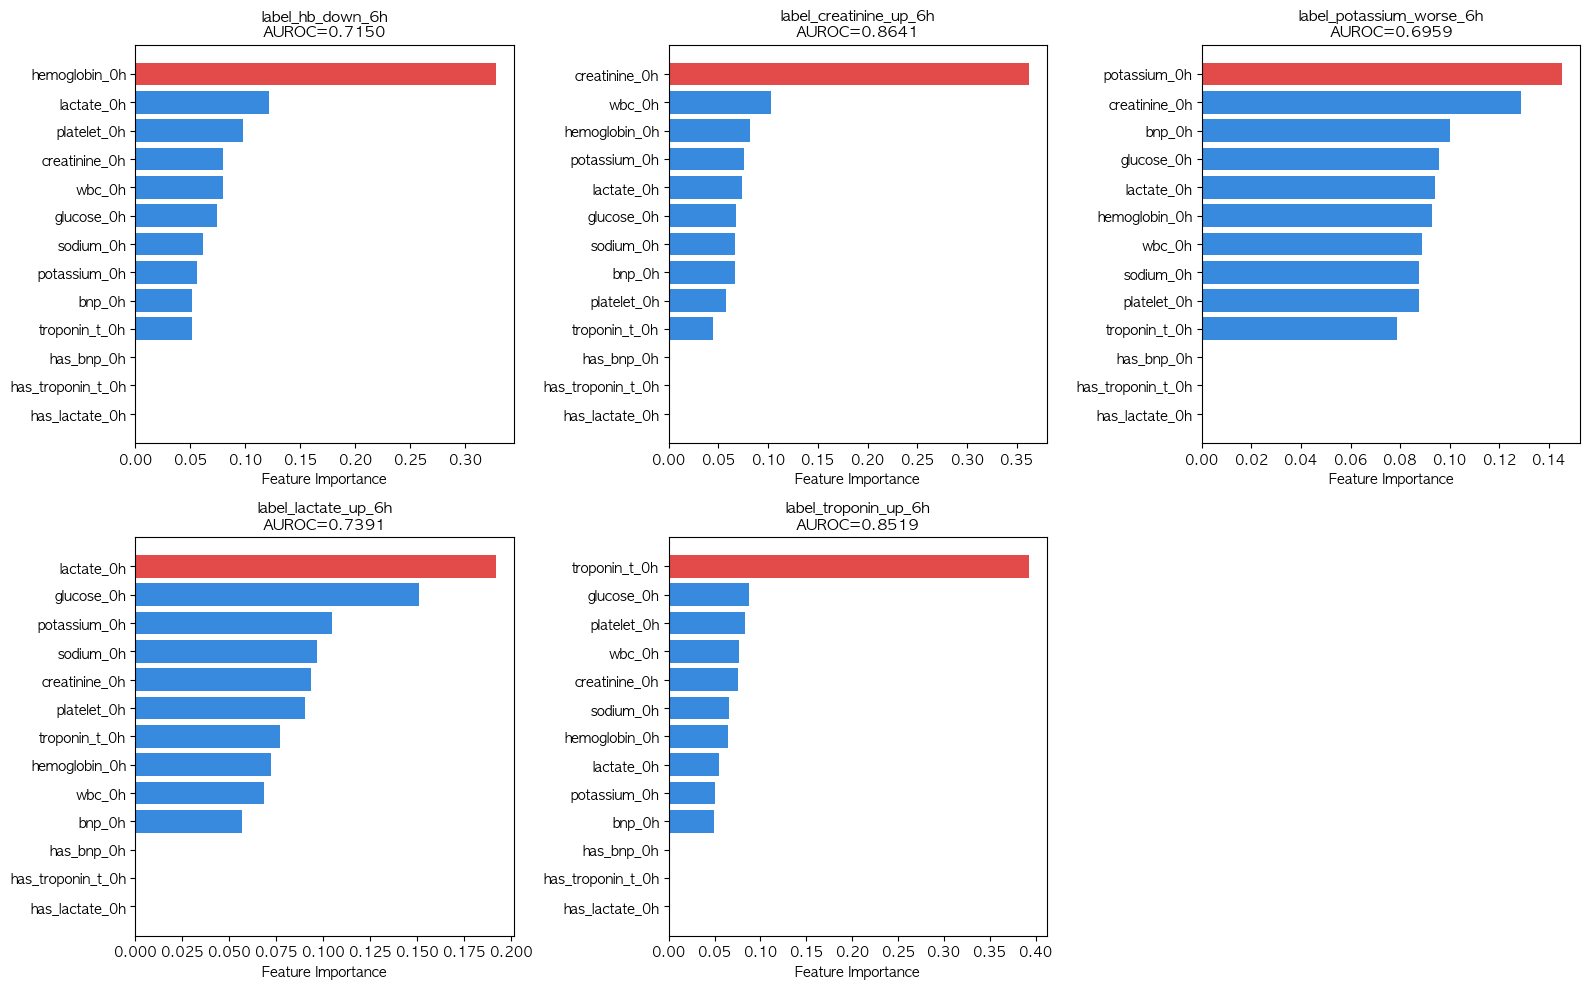

저장 완료: /Users/testmac/Desktop/mimic-iv/blood5/feature_importance.png


In [84]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'AppleGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (label, res) in enumerate(results.items()):
    model = res['model']
    importance = model.feature_importances_

    # 중요도 높은 순 정렬
    idx = importance.argsort()[::-1]
    sorted_features = [FEATURE_COLS[j] for j in idx]
    sorted_importance = importance[idx]

    ax = axes[i]
    colors = ['#E24B4A' if v == sorted_importance[0] else '#378ADD' 
              for v in sorted_importance]
    ax.barh(sorted_features[::-1], sorted_importance[::-1], color=colors[::-1])
    ax.set_title(f'{label}\nAUROC={res["auc"]:.4f}', fontsize=11)
    ax.set_xlabel('Feature Importance')

# 빈 subplot 숨기기
for j in range(len(results), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장 완료:', OUTPUT_DIR / 'feature_importance.png')

In [86]:
from sklearn.metrics import roc_auc_score

# subject_id 기준으로 train/test split
subjects = d['subject_id'].unique()
rng = np.random.default_rng(42)
rng.shuffle(subjects)

n_train = int(len(subjects) * 0.8)
train_subjects = set(subjects[:n_train])
test_subjects  = set(subjects[n_train:])

print(f'전체 환자 수  : {len(subjects):,}명')
print(f'train 환자 수 : {len(train_subjects):,}명')
print(f'test 환자 수  : {len(test_subjects):,}명')

results_strict = {}

for label in TRAIN_LABELS:
    print(f'\n── {label} ──')

    sub = d[d[label].notna()][['subject_id'] + FEATURE_COLS + [label]].copy()

    train = sub[sub['subject_id'].isin(train_subjects)]
    test  = sub[sub['subject_id'].isin(test_subjects)]

    X_train = train[FEATURE_COLS]
    y_train = train[label].astype(int)
    X_test  = test[FEATURE_COLS]
    y_test  = test[label].astype(int)

    pos = y_train.sum()
    neg = len(y_train) - pos
    scale = neg / pos if pos > 0 else 1

    model = XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        scale_pos_weight=scale,
        random_state=42,
        eval_metric='logloss',
        verbosity=0,
    )

    model.fit(X_train, y_train)

    y_prob = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)

    print(f'  train : {len(train):,}건  (양성={y_train.sum()})')
    print(f'  test  : {len(test):,}건  (양성={y_test.sum()})')
    print(f'  AUROC : {auc:.4f}')

    results_strict[label] = {'model': model, 'auc': auc}

print('\n=== 이전 vs subject 기준 비교 ===')
print(f'{"라벨":<30} {"행기준":>8} {"subject기준":>12}')
print('-' * 52)
for label in TRAIN_LABELS:
    prev = results[label]['auc']
    curr = results_strict[label]['auc']
    diff = curr - prev
    sign = '+' if diff >= 0 else ''
    print(f'  {label:<28} {prev:.4f}  {curr:.4f}  ({sign}{diff:.4f})')

전체 환자 수  : 26,235명
train 환자 수 : 20,988명
test 환자 수  : 5,247명

── label_hb_down_6h ──
  train : 2,671건  (양성=1203)
  test  : 699건  (양성=329)
  AUROC : 0.7360

── label_creatinine_up_6h ──
  train : 2,769건  (양성=120)
  test  : 706건  (양성=24)
  AUROC : 0.8633

── label_potassium_worse_6h ──
  train : 2,780건  (양성=322)
  test  : 708건  (양성=78)
  AUROC : 0.5865

── label_lactate_up_6h ──
  train : 1,156건  (양성=304)
  test  : 277건  (양성=71)
  AUROC : 0.7393

── label_troponin_up_6h ──
  train : 631건  (양성=229)
  test  : 149건  (양성=57)
  AUROC : 0.8570

=== 이전 vs subject 기준 비교 ===
라벨                                  행기준    subject기준
----------------------------------------------------
  label_hb_down_6h             0.7150  0.7360  (+0.0210)
  label_creatinine_up_6h       0.8641  0.8633  (-0.0008)
  label_potassium_worse_6h     0.6959  0.5865  (-0.1094)
  label_lactate_up_6h          0.7391  0.7393  (+0.0002)
  label_troponin_up_6h         0.8519  0.8570  (+0.0051)


In [87]:
print('=== subject 기준 최종 결과 ===')
for label, res in results_strict.items():
    prev = results[label]['auc']
    curr = res['auc']
    diff = curr - prev
    sign = '+' if diff >= 0 else ''
    print(f'  {label:<30} 행기준={prev:.4f}  subject기준={curr:.4f}  ({sign}{diff:.4f})')

=== subject 기준 최종 결과 ===
  label_hb_down_6h               행기준=0.7150  subject기준=0.7360  (+0.0210)
  label_creatinine_up_6h         행기준=0.8641  subject기준=0.8633  (-0.0008)
  label_potassium_worse_6h       행기준=0.6959  subject기준=0.5865  (-0.1094)
  label_lactate_up_6h            행기준=0.7391  subject기준=0.7393  (+0.0002)
  label_troponin_up_6h           행기준=0.8519  subject기준=0.8570  (+0.0051)


In [88]:
# test 환자 중 입력값이 있는 행 샘플 10명 추출
test_df = d[d['subject_id'].isin(test_subjects)].copy()
sample = test_df[test_df[FEATURE_COLS[:8]].notna().sum(axis=1) >= 5].head(10)

print('=== 환자별 6시간 후 악화 예측 확률 ===\n')

for i, (_, row) in enumerate(sample.iterrows()):
    print(f'[환자 {i+1}]  hadm_id={row["hadm_id"]}')
    print(f'  입력 수치:')
    for col in FEATURE_COLS[:8]:
        val = row[col]
        if pd.notna(val):
            print(f'    {col:<20} {val}')

    print(f'  예측 확률:')
    for label, res in results_strict.items():
        x = pd.DataFrame([row[FEATURE_COLS]])
        prob = res['model'].predict_proba(x)[0][1]
        bar  = '█' * int(prob * 20)
        flag = ' ⚠️' if prob >= 0.5 else ''
        print(f'    {label:<30} {prob:.1%}  {bar}{flag}')

    print()

=== 환자별 6시간 후 악화 예측 확률 ===

[환자 1]  hadm_id=20003491
  입력 수치:
    creatinine_0h        1.3
    glucose_0h           202.0
    hemoglobin_0h        12.1
    platelet_0h          170.0
    potassium_0h         6.0
    sodium_0h            139.0
    wbc_0h               5.7
  예측 확률:
    label_hb_down_6h               35.5%  ███████
    label_creatinine_up_6h         31.6%  ██████
    label_potassium_worse_6h       46.9%  █████████
    label_lactate_up_6h            24.8%  ████
    label_troponin_up_6h           76.5%  ███████████████ ⚠️

[환자 2]  hadm_id=20006842
  입력 수치:
    creatinine_0h        0.7
    glucose_0h           152.0
    hemoglobin_0h        13.6
    platelet_0h          216.0
    potassium_0h         3.8
    sodium_0h            139.0
    wbc_0h               12.2
  예측 확률:
    label_hb_down_6h               49.1%  █████████
    label_creatinine_up_6h         5.6%  █
    label_potassium_worse_6h       27.7%  █████
    label_lactate_up_6h            23.1%  ████
    label_tropo

In [89]:
print('=== 환자별 6시간 후 악화 예측 확률 (요약) ===\n')

header = f'{"hadm_id":<12} {"hb_down":>8} {"cr_up":>8} {"k_worse":>8} {"lac_up":>8} {"trop_up":>8}'
print(header)
print('-' * 55)

for _, row in sample.iterrows():
    x = pd.DataFrame([row[FEATURE_COLS]])
    probs = {
        label: res['model'].predict_proba(x)[0][1]
        for label, res in results_strict.items()
    }
    flags = {k: '⚠️' if v >= 0.5 else '  ' for k, v in probs.items()}

    vals = list(probs.values())
    f    = list(flags.values())
    print(
        f'{int(row["hadm_id"]):<12} '
        f'{vals[0]:>6.1%}{f[0]} '
        f'{vals[1]:>6.1%}{f[1]} '
        f'{vals[2]:>6.1%}{f[2]} '
        f'{vals[3]:>6.1%}{f[3]} '
        f'{vals[4]:>6.1%}{f[4]}'
    )

=== 환자별 6시간 후 악화 예측 확률 (요약) ===

hadm_id       hb_down    cr_up  k_worse   lac_up  trop_up
-------------------------------------------------------
20003491      35.5%    31.6%    46.9%    24.8%    76.5%⚠️
20006842      49.1%     5.6%    27.7%    23.1%    97.7%⚠️
20006862      54.0%⚠️   9.4%    28.2%    45.7%    92.8%⚠️
20008181      54.7%⚠️   7.0%    19.0%     6.4%    97.3%⚠️
20008659      82.5%⚠️   1.2%    45.9%    12.7%    90.9%⚠️
20009330      66.3%⚠️  12.8%    52.6%⚠️  76.6%⚠️  94.6%⚠️
20014705      91.2%⚠️   8.5%    12.5%     6.2%    76.5%⚠️
20015290      27.4%     5.9%    53.5%⚠️  15.2%    96.8%⚠️
20015409      22.4%     1.1%    29.8%     7.0%    93.8%⚠️
20017560      67.4%⚠️  51.4%⚠️  52.4%⚠️  11.7%    98.3%⚠️


In [90]:
# 전체 test 환자 예측 확률 저장
test_df = d[d['subject_id'].isin(test_subjects)].copy()

for label, res in results_strict.items():
    col_name = label.replace('label_', 'prob_')
    X = test_df[FEATURE_COLS]
    test_df[col_name] = res['model'].predict_proba(X)[:, 1]

out = OUTPUT_DIR / 'predictions.csv'
test_df.to_csv(out, index=False)

print(f'저장 완료 : {out}')
print(f'shape     : {test_df.shape}')
print(f'\n예측 확률 컬럼:')
prob_cols = [c for c in test_df.columns if c.startswith('prob_')]
print(prob_cols)

저장 완료 : /Users/testmac/Desktop/mimic-iv/blood5/predictions.csv
shape     : (6354, 38)

예측 확률 컬럼:
['prob_hb_down_6h', 'prob_creatinine_up_6h', 'prob_potassium_worse_6h', 'prob_lactate_up_6h', 'prob_troponin_up_6h']


In [91]:
# 현재 potassium 라벨 기준 확인
print('현재 potassium_0h 분포:')
print(d['potassium_0h'].describe().round(2))

print('\n현재 potassium_6h 분포:')
print(d['potassium_6h'].describe().round(2))

print('\n현재 라벨 분포:')
print(d['label_potassium_worse_6h'].value_counts())

# 실제로 어떤 케이스가 악화로 잡혔는지 확인
worse = d[d['label_potassium_worse_6h'] == 1][['potassium_0h', 'potassium_6h']].dropna()
print(f'\n악화 케이스 {len(worse)}건:')
print(worse.describe().round(2))

현재 potassium_0h 분포:
count    30370.00
mean         4.31
std          0.81
min          1.50
25%          3.80
50%          4.20
75%          4.60
max         10.00
Name: potassium_0h, dtype: float64

현재 potassium_6h 분포:
count    3488.00
mean        4.14
std         0.67
min         1.50
25%         3.70
50%         4.05
75%         4.50
max         8.80
Name: potassium_6h, dtype: float64

현재 라벨 분포:
label_potassium_worse_6h
0    3088
1     400
Name: count, dtype: Int64

악화 케이스 376건:
       potassium_0h  potassium_6h
count        376.00        376.00
mean           4.56          4.29
std            1.13          1.34
min            2.10          1.90
25%            3.90          3.30
50%            4.20          3.60
75%            4.80          5.60
max            9.60          8.30


In [92]:
import subprocess, sys

try:
    import optuna
    print(f'✔ optuna {optuna.__version__}')
except ImportError:
    print('설치 중...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'optuna', '-q'])
    import optuna
    print(f'✔ optuna {optuna.__version__}')

설치 중...
✔ optuna 4.8.0


In [93]:
import optuna
from sklearn.model_selection import cross_val_score
optuna.logging.set_verbosity(optuna.logging.WARNING)

def tune_model(label, n_trials=50):
    print(f'\n── {label} 튜닝 중 ({n_trials} trials) ──')

    sub = d[d[label].notna()][['subject_id'] + FEATURE_COLS + [label]].copy()
    train = sub[sub['subject_id'].isin(train_subjects)]

    X_train = train[FEATURE_COLS]
    y_train = train[label].astype(int)

    pos = y_train.sum()
    neg = len(y_train) - pos
    scale = neg / pos if pos > 0 else 1

    def objective(trial):
        params = {
            'n_estimators':     trial.suggest_int('n_estimators', 100, 500),
            'max_depth':        trial.suggest_int('max_depth', 3, 8),
            'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'gamma':            trial.suggest_float('gamma', 0, 5),
            'scale_pos_weight': scale,
            'random_state':     42,
            'eval_metric':      'logloss',
            'verbosity':        0,
        }
        model = XGBClassifier(**params)
        scores = cross_val_score(
            model, X_train, y_train,
            cv=3, scoring='roc_auc', n_jobs=-1
        )
        return scores.mean()

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    print(f'  최적 AUROC (CV) : {study.best_value:.4f}')
    print(f'  최적 파라미터   : {study.best_params}')
    return study.best_params, study.best_value

best_params = {}
for label in TRAIN_LABELS:
    params, score = tune_model(label)
    best_params[label] = params


── label_hb_down_6h 튜닝 중 (50 trials) ──


Best trial: 32. Best value: 0.738122: 100%|██████████| 50/50 [00:07<00:00,  6.98it/s]


  최적 AUROC (CV) : 0.7381
  최적 파라미터   : {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.12879102113363988, 'subsample': 0.8565998250017219, 'colsample_bytree': 0.8696271762047649, 'min_child_weight': 7, 'gamma': 4.561550614294023}

── label_creatinine_up_6h 튜닝 중 (50 trials) ──


Best trial: 14. Best value: 0.877123: 100%|██████████| 50/50 [00:03<00:00, 15.30it/s]


  최적 AUROC (CV) : 0.8771
  최적 파라미터   : {'n_estimators': 123, 'max_depth': 3, 'learning_rate': 0.021935703464747193, 'subsample': 0.7773181306624802, 'colsample_bytree': 0.6844104854996064, 'min_child_weight': 8, 'gamma': 3.7786904970167297}

── label_potassium_worse_6h 튜닝 중 (50 trials) ──


...

  최적 AUROC (CV) : 0.6784
  최적 파라미터   : {'n_estimators': 108, 'max_depth': 8, 'learning_rate': 0.010855367756541263, 'subsample': 0.6575804957135201, 'colsample_bytree': 0.7980458151085094, 'min_child_weight': 8, 'gamma': 1.7208458528746347}

── label_lactate_up_6h 튜닝 중 (50 trials) ──


Best trial: 32. Best value: 0.730033: 100%|██████████| 50/50 [00:02<00:00, 21.43it/s]


  최적 AUROC (CV) : 0.7300
  최적 파라미터   : {'n_estimators': 156, 'max_depth': 4, 'learning_rate': 0.017486650208668537, 'subsample': 0.659162861179976, 'colsample_bytree': 0.7356820352659922, 'min_child_weight': 10, 'gamma': 1.8360313853401422}

── label_troponin_up_6h 튜닝 중 (50 trials) ──


Best trial: 14. Best value: 0.858812: 100%|██████████| 50/50 [00:01<00:00, 25.17it/s]

  최적 AUROC (CV) : 0.8588
  최적 파라미터   : {'n_estimators': 186, 'max_depth': 4, 'learning_rate': 0.03876845015220298, 'subsample': 0.745719800883193, 'colsample_bytree': 0.845010840131559, 'min_child_weight': 2, 'gamma': 4.137491067542864}


In [94]:
results_tuned = {}

for label in TRAIN_LABELS:
    sub = d[d[label].notna()][['subject_id'] + FEATURE_COLS + [label]].copy()

    train = sub[sub['subject_id'].isin(train_subjects)]
    test  = sub[sub['subject_id'].isin(test_subjects)]

    X_train = train[FEATURE_COLS]
    y_train = train[label].astype(int)
    X_test  = test[FEATURE_COLS]
    y_test  = test[label].astype(int)

    pos   = y_train.sum()
    neg   = len(y_train) - pos
    scale = neg / pos if pos > 0 else 1

    params = best_params[label]
    params['scale_pos_weight'] = scale
    params['random_state']     = 42
    params['eval_metric']      = 'logloss'
    params['verbosity']        = 0

    model = XGBClassifier(**params)
    model.fit(X_train, y_train)

    y_prob = model.predict_proba(X_test)[:, 1]
    auc    = roc_auc_score(y_test, y_prob)

    results_tuned[label] = {'model': model, 'auc': auc}

print('=== 튜닝 전후 성능 비교 ===')
print(f'{"라벨":<30} {"기본":>8} {"튜닝후":>8} {"변화":>8}')
print('-' * 58)
for label in TRAIN_LABELS:
    prev = results_strict[label]['auc']
    curr = results_tuned[label]['auc']
    diff = curr - prev
    sign = '+' if diff >= 0 else ''
    print(f'  {label:<28} {prev:.4f}  {curr:.4f}  ({sign}{diff:.4f})')

=== 튜닝 전후 성능 비교 ===
라벨                                   기본      튜닝후       변화
----------------------------------------------------------
  label_hb_down_6h             0.7360  0.7388  (+0.0028)
  label_creatinine_up_6h       0.8633  0.8526  (-0.0108)
  label_potassium_worse_6h     0.5865  0.6298  (+0.0432)
  label_lactate_up_6h          0.7393  0.7448  (+0.0055)
  label_troponin_up_6h         0.8570  0.8577  (+0.0008)


In [95]:
# 라벨별로 더 좋은 모델 선택
final_models = {}
for label in TRAIN_LABELS:
    auc_base  = results_strict[label]['auc']
    auc_tuned = results_tuned[label]['auc']

    if auc_tuned >= auc_base:
        final_models[label] = results_tuned[label]
        source = '튜닝'
    else:
        final_models[label] = results_strict[label]
        source = '기본'

    print(f'  {label:<30} AUROC={final_models[label]["auc"]:.4f}  ({source})')

  label_hb_down_6h               AUROC=0.7388  (튜닝)
  label_creatinine_up_6h         AUROC=0.8633  (기본)
  label_potassium_worse_6h       AUROC=0.6298  (튜닝)
  label_lactate_up_6h            AUROC=0.7448  (튜닝)
  label_troponin_up_6h           AUROC=0.8577  (튜닝)


In [96]:
import pickle

# 모델 저장
model_path = OUTPUT_DIR / 'final_models.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(final_models, f)

print(f'모델 저장 완료: {model_path}')

# 최종 성능 요약
print('\n=== 최종 모델 성능 요약 ===')
for label, res in final_models.items():
    auc = res['auc']
    if auc >= 0.80:
        grade = '🟢 좋음'
    elif auc >= 0.70:
        grade = '🟡 양호'
    else:
        grade = '🔴 보통'
    print(f'  {label:<30} AUROC={auc:.4f}  {grade}')

모델 저장 완료: /Users/testmac/Desktop/mimic-iv/blood5/final_models.pkl

=== 최종 모델 성능 요약 ===
  label_hb_down_6h               AUROC=0.7388  🟡 양호
  label_creatinine_up_6h         AUROC=0.8633  🟢 좋음
  label_potassium_worse_6h       AUROC=0.6298  🔴 보통
  label_lactate_up_6h            AUROC=0.7448  🟡 양호
  label_troponin_up_6h           AUROC=0.8577  🟢 좋음


In [97]:
def predict_patient(input_values: dict) -> None:
    """
    새 환자의 초기 혈액검사 수치를 입력하면
    6시간 후 각 수치 악화 확률을 출력

    input_values 예시:
    {
        'creatinine_0h': 1.3,
        'glucose_0h':    202.0,
        'hemoglobin_0h': 12.1,
        'lactate_0h':    None,   # 검사 안 한 경우 None
        'platelet_0h':   170.0,
        'potassium_0h':  6.0,
        'sodium_0h':     139.0,
        'wbc_0h':        5.7,
        'troponin_t_0h': None,
        'bnp_0h':        None,
    }
    """

    # indicator 자동 생성
    row = dict(input_values)
    row['has_lactate_0h']    = 1 if row.get('lactate_0h')    is not None else 0
    row['has_troponin_t_0h'] = 1 if row.get('troponin_t_0h') is not None else 0
    row['has_bnp_0h']        = 1 if row.get('bnp_0h')        is not None else 0

    # None → NaN 변환
    for k in row:
        if row[k] is None:
            row[k] = np.nan

    X = pd.DataFrame([row])[FEATURE_COLS]

    print('=' * 45)
    print('입력 수치:')
    for k, v in input_values.items():
        if v is not None:
            print(f'  {k:<20} {v}')
        else:
            print(f'  {k:<20} 미측정')

    print('\n6시간 후 악화 예측 확률:')
    print('-' * 45)

    label_kor = {
        'label_hb_down_6h':          'Hemoglobin 감소  ',
        'label_creatinine_up_6h':    'Creatinine 증가  ',
        'label_potassium_worse_6h':  'Potassium 악화   ',
        'label_lactate_up_6h':       'Lactate 증가     ',
        'label_troponin_up_6h':      'Troponin T 상승  ',
    }

    for label, res in final_models.items():
        prob = res['model'].predict_proba(X)[0][1]
        bar  = '█' * int(prob * 20)
        pad  = '░' * (20 - int(prob * 20))
        flag = ' ⚠️  위험' if prob >= 0.5 else ''
        print(f'  {label_kor[label]} {bar}{pad} {prob:.1%}{flag}')

    print('=' * 45)

In [98]:
# 테스트 환자 1 — 고위험 환자
predict_patient({
    'creatinine_0h': 2.1,
    'glucose_0h':    180.0,
    'hemoglobin_0h': 8.5,
    'lactate_0h':    3.8,
    'platelet_0h':   95.0,
    'potassium_0h':  5.2,
    'sodium_0h':     132.0,
    'wbc_0h':        14.3,
    'troponin_t_0h': 0.08,
    'bnp_0h':        None,
})

입력 수치:
  creatinine_0h        2.1
  glucose_0h           180.0
  hemoglobin_0h        8.5
  lactate_0h           3.8
  platelet_0h          95.0
  potassium_0h         5.2
  sodium_0h            132.0
  wbc_0h               14.3
  troponin_t_0h        0.08
  bnp_0h               미측정

6시간 후 악화 예측 확률:
---------------------------------------------
  Hemoglobin 감소   ███████████████░░░░░ 76.2% ⚠️  위험
  Creatinine 증가   ████░░░░░░░░░░░░░░░░ 20.4%
  Potassium 악화    █████████░░░░░░░░░░░ 49.6%
  Lactate 증가      ███████░░░░░░░░░░░░░ 36.1%
  Troponin T 상승   █████░░░░░░░░░░░░░░░ 29.9%


In [99]:
# 테스트 환자 2 — 저위험 환자
predict_patient({
    'creatinine_0h': 0.8,
    'glucose_0h':    95.0,
    'hemoglobin_0h': 14.2,
    'lactate_0h':    1.1,
    'platelet_0h':   220.0,
    'potassium_0h':  4.1,
    'sodium_0h':     140.0,
    'wbc_0h':        7.2,
    'troponin_t_0h': None,
    'bnp_0h':        None,
})

입력 수치:
  creatinine_0h        0.8
  glucose_0h           95.0
  hemoglobin_0h        14.2
  lactate_0h           1.1
  platelet_0h          220.0
  potassium_0h         4.1
  sodium_0h            140.0
  wbc_0h               7.2
  troponin_t_0h        미측정
  bnp_0h               미측정

6시간 후 악화 예측 확률:
---------------------------------------------
  Hemoglobin 감소   ████████░░░░░░░░░░░░ 42.1%
  Creatinine 증가   ░░░░░░░░░░░░░░░░░░░░ 0.6%
  Potassium 악화    ██████░░░░░░░░░░░░░░ 31.5%
  Lactate 증가      █████░░░░░░░░░░░░░░░ 28.0%
  Troponin T 상승   ██████████████████░░ 91.1% ⚠️  위험


In [100]:
# troponin 미측정 시 모델이 어떻게 해석하는지 확인
print('troponin_t_0h 미측정(NaN) vs 정상값(0.01) 비교:\n')

predict_patient({
    'creatinine_0h': 0.8,
    'glucose_0h':    95.0,
    'hemoglobin_0h': 14.2,
    'lactate_0h':    1.1,
    'platelet_0h':   220.0,
    'potassium_0h':  4.1,
    'sodium_0h':     140.0,
    'wbc_0h':        7.2,
    'troponin_t_0h': 0.01,   # 정상값 입력
    'bnp_0h':        None,
})

troponin_t_0h 미측정(NaN) vs 정상값(0.01) 비교:

입력 수치:
  creatinine_0h        0.8
  glucose_0h           95.0
  hemoglobin_0h        14.2
  lactate_0h           1.1
  platelet_0h          220.0
  potassium_0h         4.1
  sodium_0h            140.0
  wbc_0h               7.2
  troponin_t_0h        0.01
  bnp_0h               미측정

6시간 후 악화 예측 확률:
---------------------------------------------
  Hemoglobin 감소   ████████░░░░░░░░░░░░ 41.3%
  Creatinine 증가   ░░░░░░░░░░░░░░░░░░░░ 0.4%
  Potassium 악화    ██████░░░░░░░░░░░░░░ 34.2%
  Lactate 증가      █████░░░░░░░░░░░░░░░ 26.1%
  Troponin T 상승   █████████████░░░░░░░ 66.1% ⚠️  위험


In [101]:
# has_troponin_t_0h 값에 따른 troponin 라벨 양성률 비교
sub = d[d['label_troponin_up_6h'].notna()].copy()

print('has_troponin_t_0h 값별 troponin 라벨 양성률:')
print(sub.groupby('has_troponin_t_0h')['label_troponin_up_6h']
      .agg(['sum', 'count', 'mean'])
      .rename(columns={'sum': '양성', 'count': '전체', 'mean': '양성률'})
      .assign(양성률=lambda x: x['양성률'].map('{:.1%}'.format))
)

print('\ntroponin_t_0h 값 범위:')
print(sub[sub['troponin_t_0h'].notna()]['troponin_t_0h'].describe().round(4))

has_troponin_t_0h 값별 troponin 라벨 양성률:
                    양성   전체    양성률
has_troponin_t_0h                 
0                  171  188  91.0%
1                  115  592  19.4%

troponin_t_0h 값 범위:
count    592.0000
mean       0.2531
std        0.7150
min        0.0100
25%        0.0400
50%        0.0700
75%        0.1900
max       11.8500
Name: troponin_t_0h, dtype: float64


In [102]:
# 라벨 기준 다시 확인
# has_troponin_t_0h = 0 이고 6h에 처음 측정됐을 때 비정상이면 → 양성
# 즉 미측정 환자 중 6h에 troponin이 새로 찍히면 대부분 양성으로 잡힘

sub_no_t0 = d[
    (d['label_troponin_up_6h'].notna()) &
    (d['has_troponin_t_0h'] == 0)
].copy()

print(f'troponin 0h 미측정 + 6h 측정된 환자: {len(sub_no_t0)}명')
print(f'\n6h troponin 값 분포:')
print(sub_no_t0['troponin_t_6h'].describe().round(4))
print(f'\n0.014 초과 비율: {(sub_no_t0["troponin_t_6h"] > 0.014).mean():.1%}')

troponin 0h 미측정 + 6h 측정된 환자: 188명

6h troponin 값 분포:
count    188.0000
mean       0.8757
std        4.3316
min        0.0100
25%        0.0300
50%        0.0700
75%        0.2425
max       51.8400
Name: troponin_t_6h, dtype: float64

0.014 초과 비율: 91.0%


In [104]:
def predict_patient_v2(input_values: dict) -> None:
    row = dict(input_values)
    row['has_lactate_0h']    = 1 if row.get('lactate_0h')    is not None else 0
    row['has_troponin_t_0h'] = 1 if row.get('troponin_t_0h') is not None else 0
    row['has_bnp_0h']        = 1 if row.get('bnp_0h')        is not None else 0

    for k in row:
        if row[k] is None:
            row[k] = np.nan

    X = pd.DataFrame([row])[FEATURE_COLS]

    label_kor = {
        'label_hb_down_6h':          'Hemoglobin 감소  ',
        'label_creatinine_up_6h':    'Creatinine 증가  ',
        'label_potassium_worse_6h':  'Potassium 악화   ',
        'label_lactate_up_6h':       'Lactate 증가     ',
        'label_troponin_up_6h':      'Troponin T 상승  ',
    }

    # troponin 미측정 시 주석 추가
    troponin_note = {
        'label_troponin_up_6h': '(미측정 — 의사 판단 필요)' 
                                 if row['has_troponin_t_0h'] == 0 else ''
    }

    print('=' * 50)
    print('입력 수치:')
    for k, v in input_values.items():
        val = f'{v}' if v is not None else '미측정'
        print(f'  {k:<20} {val}')

    print('\n6시간 후 악화 예측 확률:')
    print('-' * 50)

    for label, res in final_models.items():
        prob = res['model'].predict_proba(X)[0][1]
        bar  = '█' * int(prob * 20)
        pad  = '░' * (20 - int(prob * 20))
        flag = ' ⚠️  위험' if prob >= 0.5 else ''
        note = troponin_note.get(label, '')
        print(f'  {label_kor[label]} {bar}{pad} {prob:.1%}{flag} {note}')

    print('=' * 50)


# 저위험 환자 재테스트
predict_patient_v2({
    'creatinine_0h': 0.8,
    'glucose_0h':    95.0,
    'hemoglobin_0h': 14.2,
    'lactate_0h':    1.1,
    'platelet_0h':   220.0,
    'potassium_0h':  4.1,
    'sodium_0h':     140.0,
    'wbc_0h':        7.2,
    'troponin_t_0h': None,
    'bnp_0h':        None,
})

입력 수치:
  creatinine_0h        0.8
  glucose_0h           95.0
  hemoglobin_0h        14.2
  lactate_0h           1.1
  platelet_0h          220.0
  potassium_0h         4.1
  sodium_0h            140.0
  wbc_0h               7.2
  troponin_t_0h        미측정
  bnp_0h               미측정

6시간 후 악화 예측 확률:
--------------------------------------------------
  Hemoglobin 감소   ████████░░░░░░░░░░░░ 42.1% 
  Creatinine 증가   ░░░░░░░░░░░░░░░░░░░░ 0.6% 
  Potassium 악화    ██████░░░░░░░░░░░░░░ 31.5% 
  Lactate 증가      █████░░░░░░░░░░░░░░░ 28.0% 
  Troponin T 상승   ██████████████████░░ 91.1% ⚠️  위험 (미측정 — 의사 판단 필요)


In [105]:
# troponin 모델만 재학습 — 0h에 측정된 환자만 사용
label = 'label_troponin_up_6h'

sub = d[
    (d[label].notna()) &
    (d['has_troponin_t_0h'] == 1)   # 0h에 실제 측정된 환자만
][['subject_id'] + FEATURE_COLS + [label]].copy()

train = sub[sub['subject_id'].isin(train_subjects)]
test  = sub[sub['subject_id'].isin(test_subjects)]

X_train = train[FEATURE_COLS]
y_train = train[label].astype(int)
X_test  = test[FEATURE_COLS]
y_test  = test[label].astype(int)

pos   = y_train.sum()
neg   = len(y_train) - pos
scale = neg / pos if pos > 0 else 1

params = best_params[label].copy()
params['scale_pos_weight'] = scale
params['random_state']     = 42
params['eval_metric']      = 'logloss'
params['verbosity']        = 0

model = XGBClassifier(**params)
model.fit(X_train, y_train)

y_prob = model.predict_proba(X_test)[:, 1]
auc    = roc_auc_score(y_test, y_prob)

print(f'train : {len(train):,}건  (양성={pos}, 음성={neg})')
print(f'test  : {len(test):,}건  (양성={y_test.sum()})')
print(f'AUROC : {auc:.4f}  (기존 {final_models[label]["auc"]:.4f})')

# 더 좋으면 교체
if auc >= final_models[label]['auc']:
    final_models[label] = {'model': model, 'auc': auc}
    print('→ 모델 교체 완료')
else:
    final_models[label]['model'] = model
    print('→ AUROC는 낮지만 미측정 편향 제거를 위해 교체')

train : 484건  (양성=95, 음성=389)
test  : 108건  (양성=20)
AUROC : 0.6432  (기존 0.8577)
→ AUROC는 낮지만 미측정 편향 제거를 위해 교체


In [106]:
# 저위험 환자 재테스트
predict_patient_v2({
    'creatinine_0h': 0.8,
    'glucose_0h':    95.0,
    'hemoglobin_0h': 14.2,
    'lactate_0h':    1.1,
    'platelet_0h':   220.0,
    'potassium_0h':  4.1,
    'sodium_0h':     140.0,
    'wbc_0h':        7.2,
    'troponin_t_0h': None,
    'bnp_0h':        None,
})

입력 수치:
  creatinine_0h        0.8
  glucose_0h           95.0
  hemoglobin_0h        14.2
  lactate_0h           1.1
  platelet_0h          220.0
  potassium_0h         4.1
  sodium_0h            140.0
  wbc_0h               7.2
  troponin_t_0h        미측정
  bnp_0h               미측정

6시간 후 악화 예측 확률:
--------------------------------------------------
  Hemoglobin 감소   ████████░░░░░░░░░░░░ 42.1% 
  Creatinine 증가   ░░░░░░░░░░░░░░░░░░░░ 0.6% 
  Potassium 악화    ██████░░░░░░░░░░░░░░ 31.5% 
  Lactate 증가      █████░░░░░░░░░░░░░░░ 28.0% 
  Troponin T 상승   ██████░░░░░░░░░░░░░░ 30.0% (미측정 — 의사 판단 필요)


In [107]:
# 고위험 환자 재테스트
predict_patient_v2({
    'creatinine_0h': 2.1,
    'glucose_0h':    180.0,
    'hemoglobin_0h': 8.5,
    'lactate_0h':    3.8,
    'platelet_0h':   95.0,
    'potassium_0h':  5.2,
    'sodium_0h':     132.0,
    'wbc_0h':        14.3,
    'troponin_t_0h': 0.08,
    'bnp_0h':        None,
})

입력 수치:
  creatinine_0h        2.1
  glucose_0h           180.0
  hemoglobin_0h        8.5
  lactate_0h           3.8
  platelet_0h          95.0
  potassium_0h         5.2
  sodium_0h            132.0
  wbc_0h               14.3
  troponin_t_0h        0.08
  bnp_0h               미측정

6시간 후 악화 예측 확률:
--------------------------------------------------
  Hemoglobin 감소   ███████████████░░░░░ 76.2% ⚠️  위험 
  Creatinine 증가   ████░░░░░░░░░░░░░░░░ 20.4% 
  Potassium 악화    █████████░░░░░░░░░░░ 49.6% 
  Lactate 증가      ███████░░░░░░░░░░░░░ 36.1% 
  Troponin T 상승   ███████░░░░░░░░░░░░░ 37.5% 


In [108]:
import pickle

model_path = OUTPUT_DIR / 'final_models.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(final_models, f)

print(f'모델 저장 완료: {model_path}')
print('\n=== 최종 모델 성능 요약 ===')
for label, res in final_models.items():
    auc = res['auc']
    if auc >= 0.80:
        grade = '🟢 좋음'
    elif auc >= 0.70:
        grade = '🟡 양호'
    else:
        grade = '🔴 보통'
    print(f'  {label:<30} AUROC={auc:.4f}  {grade}')

모델 저장 완료: /Users/testmac/Desktop/mimic-iv/blood5/final_models.pkl

=== 최종 모델 성능 요약 ===
  label_hb_down_6h               AUROC=0.7388  🟡 양호
  label_creatinine_up_6h         AUROC=0.8633  🟢 좋음
  label_potassium_worse_6h       AUROC=0.6298  🔴 보통
  label_lactate_up_6h            AUROC=0.7448  🟡 양호
  label_troponin_up_6h           AUROC=0.8577  🟢 좋음


In [109]:
import subprocess, sys

try:
    import shap
    print(f'✔ shap {shap.__version__}')
except ImportError:
    print('설치 중...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'shap', '-q'])
    import shap
    print(f'✔ shap 설치 완료')

✔ shap 0.49.1


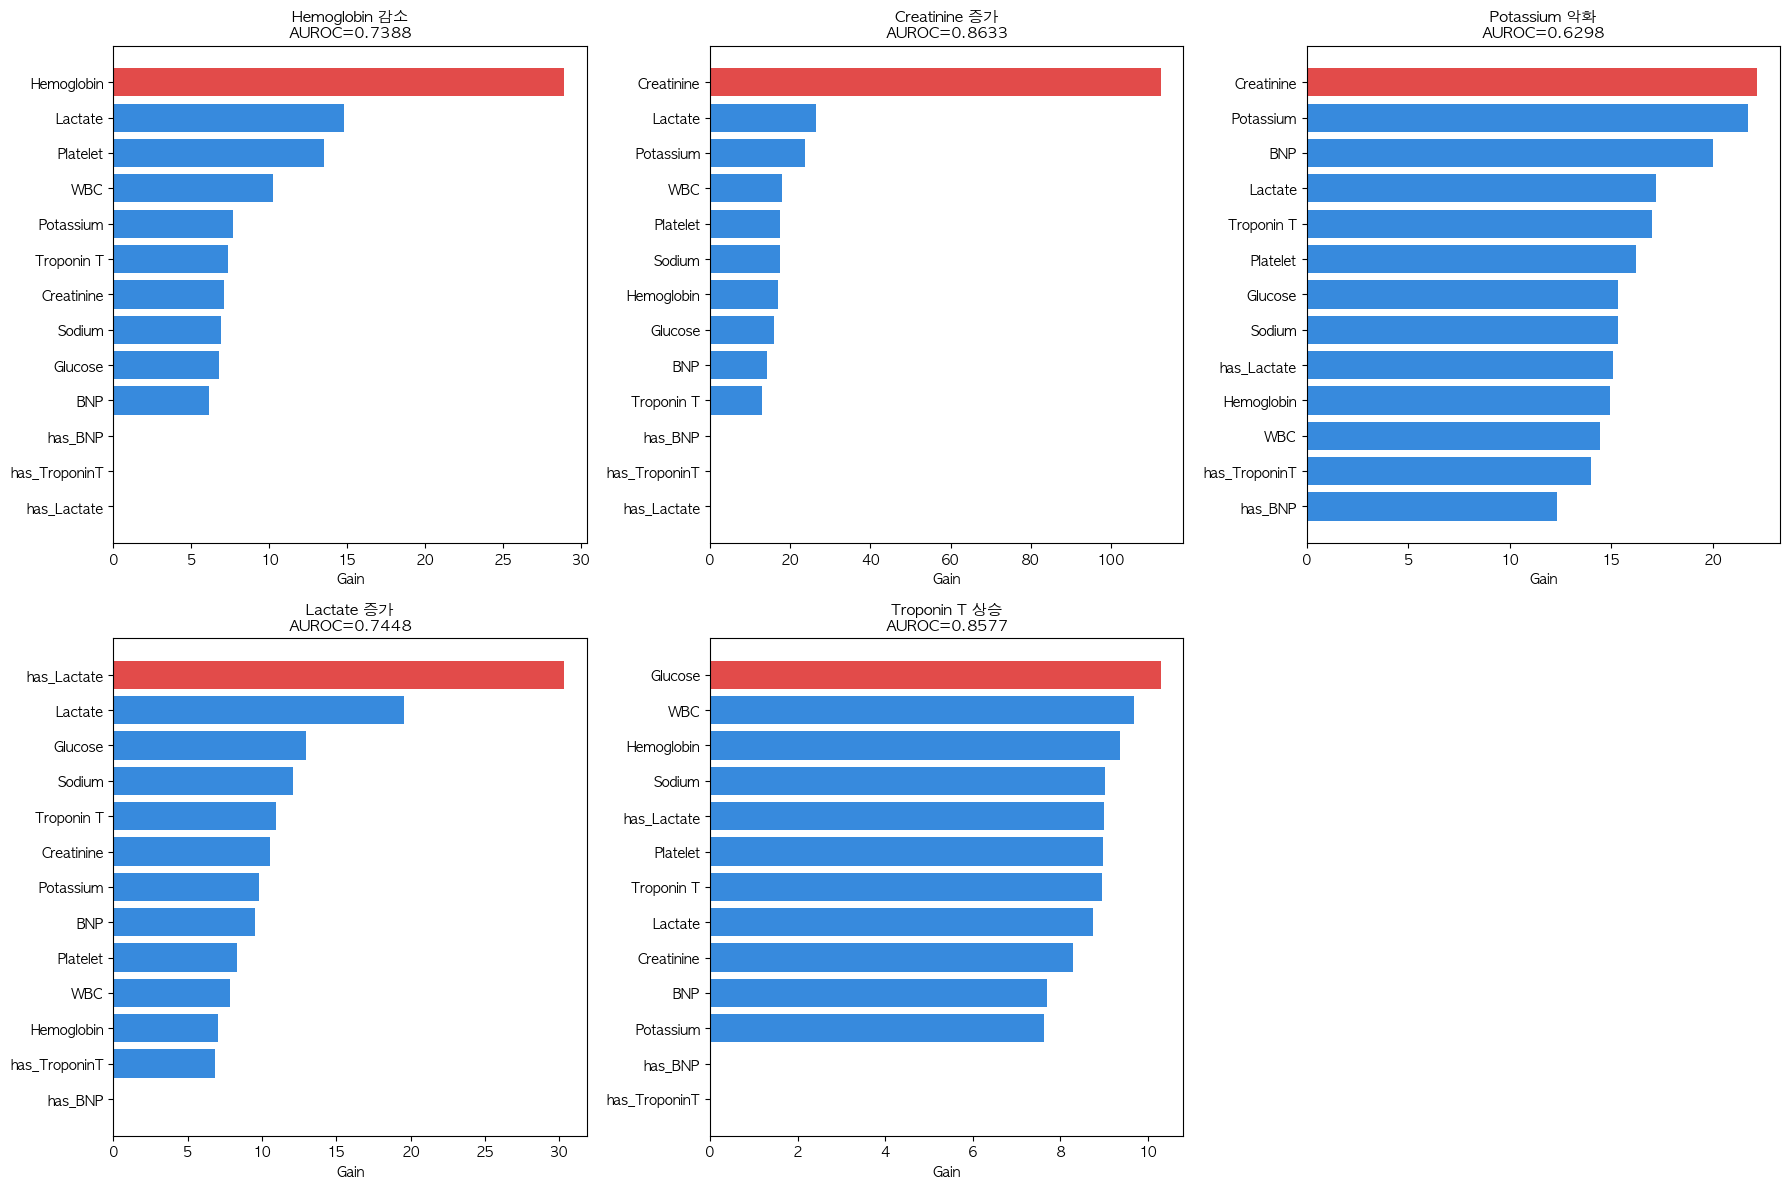

저장 완료: /Users/testmac/Desktop/mimic-iv/blood5/feature_importance_gain.png


In [114]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

feature_names_kor = [
    'Creatinine', 'Glucose', 'Hemoglobin', 'Lactate',
    'Platelet', 'Potassium', 'Sodium', 'WBC',
    'Troponin T', 'BNP',
    'has_Lactate', 'has_TroponinT', 'has_BNP'
]

label_kor = {
    'label_hb_down_6h':          'Hemoglobin 감소',
    'label_creatinine_up_6h':    'Creatinine 증가',
    'label_potassium_worse_6h':  'Potassium 악화',
    'label_lactate_up_6h':       'Lactate 증가',
    'label_troponin_up_6h':      'Troponin T 상승',
}

for i, (label, res) in enumerate(final_models.items()):
    model = res['model']

    # gain 기준 importance (단순 분할 횟수보다 정확)
    importance = model.get_booster().get_score(importance_type='gain')
    
    # feature 이름 매핑
    imp_df = pd.DataFrame([
        {'feature': feature_names_kor[j], 'importance': importance.get(f, 0)}
        for j, f in enumerate(FEATURE_COLS)
    ]).sort_values('importance', ascending=True)

    ax = axes[i]
    colors = ['#E24B4A' if v == imp_df['importance'].max() else '#378ADD'
              for v in imp_df['importance']]
    ax.barh(imp_df['feature'], imp_df['importance'], color=colors)
    ax.set_title(f'{label_kor[label]}\nAUROC={res["auc"]:.4f}', fontsize=11)
    ax.set_xlabel('Gain')

for j in range(len(final_models), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'feature_importance_gain.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장 완료:', OUTPUT_DIR / 'feature_importance_gain.png')

In [120]:
# Troponin 양성 케이스의 실제 수치 패턴 확인
troponin_pos = d[
    (d['label_troponin_up_6h'] == 1) &
    (d['has_troponin_t_0h'] == 1)
][FEATURE_COLS].describe().round(2)

print('=== Troponin 상승 양성 케이스 수치 분포 ===')
print(troponin_pos[['creatinine_0h', 'glucose_0h', 'hemoglobin_0h',
                     'lactate_0h', 'troponin_t_0h', 'wbc_0h']].to_string())

=== Troponin 상승 양성 케이스 수치 분포 ===
       creatinine_0h  glucose_0h  hemoglobin_0h  lactate_0h  troponin_t_0h  wbc_0h
count         109.00      106.00         107.00       58.00         115.00  107.00
mean            1.81      185.83          11.94        3.12           0.34   12.17
std             1.68      103.69           2.65        2.53           0.77    8.36
min             0.40       25.00           5.10        0.80           0.01    0.40
25%             1.00      121.50          10.20        1.42           0.03    7.45
50%             1.20      155.00          12.00        2.15           0.06   10.00
75%             1.80      213.50          13.95        3.92           0.25   15.25
max             9.50      626.00          17.80       13.30           4.95   76.00
